In [1]:
from itertools import product
import pandas as pd
import numpy as np
import scipy.io
import os

from RLWK.rlwk import Rlwk
from sklearn.cluster import KMeans
from coclust.clustering.spherical_kmeans import SphericalKmeans

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics import normalized_mutual_info_score,adjusted_rand_score
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS
from sklearn.metrics import silhouette_score
from nltk.stem import WordNetLemmatizer
import re

import matplotlib.pyplot as plt
import seaborn as sns

## Import data

In [2]:
"""
tfidf 
    * CLASSIC3 | OHSCALE | CSTR | CLASSIC4  | TR45 | SPORTS
    * BBC | NG5 | NG20 
    * HM_ng20 | HM_bbc | HM_pubmed5 | HM_pubmed10 | HM_classic4
"""

data_type = 'tfidf' 
data_name = 'CSTR'

# Load dict file
mat = scipy.io.loadmat(os.path.join('new_data', data_type,data_name))

# Load labels
y = mat['labels'].flatten()
mat = mat['mat'].toarray()
k = len(set(y))

print('Shape :',mat.shape)
print('k :',k)


Shape : (475, 1000)
k : 4


__Grid search__

In [7]:
def grid_search_rlwk(X, y, k, grid_param, n_iter):
    best_accuracy = 0
    best_params = None

    for params in product(*grid_param.values()): 
        param_dict = dict(zip(grid_param.keys(), params))
        
        print("Current Parameters:", param_dict)
        res_nmi, res_ari = [],[]
        
        for i in range(n_iter):
            print('Iteration',i+1,'/',n_iter,end="\r")
            rlwk = Rlwk(k=k, **param_dict)
            rlwk.fit(X, verbose=0)
            res_nmi += [normalized_mutual_info_score(rlwk.labels_,y)]
            res_ari += [adjusted_rand_score(rlwk.labels_,y)]
            if int(10*res_nmi[0])==0 : 
                break

        if n_iter != 0:
            print(f'Summary :\nNMI: {np.mean(res_nmi):.2f} +/- {np.std(res_nmi):.2f} \nARI: {np.mean(res_ari):.2f} +/- {np.std(res_ari):.2f}')

        print("-" * 80)

In [15]:
n_iter = 5
grid_param = { 
    'lambda_val': [1e-5,1e-4, 1e-3, 1e-2, 1e-1],  
    'alpha': [0.1,0.5,1,0], #The value 0 corresponds to the formula presented in section 4.2 Selection of Tuning Parameters
    'beta': [3] ,
    'chi2': [True],
    'scale': [False],
    'init' : 's'
}
grid_search_rlwk(mat, y, k, grid_param, n_iter=n_iter)

Current Parameters: {'lambda_val': 1e-05, 'alpha': 0.1, 'beta': 3, 'chi2': True, 'scale': False, 'init': 's'}
Summary : 5 / 5
NMI: 0.72 +/- 0.02 
ARI: 0.76 +/- 0.02
--------------------------------------------------------------------------------
Current Parameters: {'lambda_val': 1e-05, 'alpha': 0.5, 'beta': 3, 'chi2': True, 'scale': False, 'init': 's'}
Summary : 5 / 5
NMI: 0.72 +/- 0.02 
ARI: 0.73 +/- 0.06
--------------------------------------------------------------------------------
Current Parameters: {'lambda_val': 1e-05, 'alpha': 1, 'beta': 3, 'chi2': True, 'scale': False, 'init': 's'}
Summary : 5 / 5
NMI: 0.69 +/- 0.04 
ARI: 0.70 +/- 0.06
--------------------------------------------------------------------------------
Current Parameters: {'lambda_val': 0.0001, 'alpha': 0.1, 'beta': 3, 'chi2': True, 'scale': False, 'init': 's'}
Summary : 5 / 5
NMI: 0.74 +/- 0.03 
ARI: 0.77 +/- 0.04
--------------------------------------------------------------------------------
Current Parameter

__Simple usage of R-Lwk__

In [3]:
lamb = 0.00001    
alpha = 0   #The value 0 corresponds to the formula presented in section 4.2 Selection of Tuning Parameters
beta = 4   
scale = 0
chi2 = 1
n = 10
init = 's'

res_nmi, res_ari = [],[]
silh, p2 = [],[]

for i in range(n):
    print('Iteration',i+1,'/',n,end="\r")
    rlwk = Rlwk(k, lambda_val=lamb, alpha=alpha, beta=beta, chi2=chi2, scale=scale, init = init, )#z=np.array(sk.row_labels_))
    rlwk.fit(mat, verbose=0)
    
    res_nmi += [normalized_mutual_info_score(rlwk.labels_,y)]
    res_ari += [adjusted_rand_score(rlwk.labels_,y)]
    
    silh.append(silhouette_score(mat, rlwk.labels_))
    p2.append(rlwk.P2)

best_nmi = [i[0] for i in sorted(zip(res_nmi, silh), key=lambda x: x[1], reverse=True)][:5]
best_ari = [i[0] for i in sorted(zip(res_ari, silh), key=lambda x: x[1], reverse=True)][:5]

best_nmi_p2 = [i[0] for i in sorted(zip(res_nmi, p2), key=lambda x: x[1], reverse=0)][:5]
best_ari_p2 = [i[0] for i in sorted(zip(res_ari, p2), key=lambda x: x[1], reverse=0)][:5]

print(f'Top 5 results Silhouette :  \nNMI: {np.mean(best_nmi):.2f} +/- {np.std(best_nmi):.2f} \nARI: {np.mean(best_ari):.2f} +/- {np.std(best_ari):.2f}')
print(f'Top 5 results P :  \nNMI: {np.mean(best_nmi_p2):.2f} +/- {np.std(best_nmi_p2):.2f} \nARI: {np.mean(best_ari_p2):.2f} +/- {np.std(best_ari_p2):.2f}')
print(f'Mean \nNMI: {np.mean(res_nmi):.2f} +/- {np.std(res_nmi):.2f} \nARI: {np.mean(res_ari):.2f} +/- {np.std(res_ari):.2f}')

Top 5 results Silhouette :  
NMI: 0.77 +/- 0.02 
ARI: 0.81 +/- 0.02
Top 5 results P :  
NMI: 0.71 +/- 0.02 
ARI: 0.73 +/- 0.03
Mean 
NMI: 0.74 +/- 0.04 
ARI: 0.77 +/- 0.05


__Test skmeans__

In [30]:
n = 1
res_nmi, res_ari, silh = [],[],[]
for i in range(n):
    print('Iteration',i+1,'/',n,end="\r")
    mat = mat #mat_supp mat_tfidf.toarray()
    sk = SphericalKmeans(n_clusters=k, n_init=20)
    sk.fit(mat)
    res_nmi += [normalized_mutual_info_score(sk.row_labels_,y)]
    res_ari += [adjusted_rand_score(sk.row_labels_,y)]

# Best mean
print(f'\nMean \nNMI: {np.mean(res_nmi):.2f} +/- {np.std(res_nmi):.2f} \nARI: {np.mean(res_ari):.2f} +/- {np.std(res_ari):.2f}')

Iteration 1 / 1
Mean 
NMI: 0.68 +/- 0.00 
ARI: 0.72 +/- 0.00


__Test k-means__

In [6]:
n = 15
res_nmi, res_ari = [],[]
for i in range(n):
    print('Iteration',i+1,'/',n,end="\r")
    mat = mat#.toarray() #mat_supp mat_tfidf.toarray()
    kmeans = KMeans(n_clusters=k, n_init=20).fit(mat)
    res_nmi += [normalized_mutual_info_score(kmeans.labels_,y)]
    res_ari += [adjusted_rand_score(kmeans.labels_,y)]

# Best mean
print(f'\nMean \nNMI: {np.mean(res_nmi):.2f} +/- {np.std(res_nmi):.2f} \nARI: {np.mean(res_ari):.2f} +/- {np.std(res_ari):.2f}')

Iteration 15 / 15
Mean 
NMI: 0.62 +/- 0.02 
ARI: 0.52 +/- 0.03


## <span style="color:Red">Analysis</span>### I. Weights

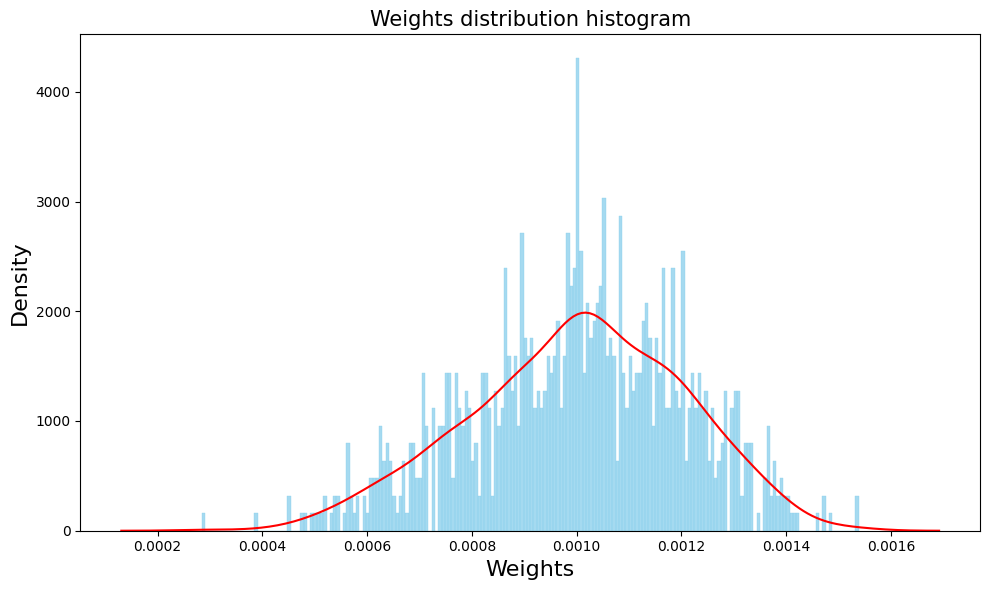

In [7]:
weights = rlwk.weights_.T
plt.figure(figsize=(10, 6))

# Histogramme
sns.histplot(weights, bins=200, kde=False, stat='density', color='skyblue', edgecolor='skyblue')
sns.kdeplot(weights, color='red')
plt.title('Weights distribution histogram', fontsize=15)
plt.xlabel('Weights', fontsize=16)
plt.ylabel('Density', fontsize=16)


# Ajustement des graphiques
plt.tight_layout()
plt.show()

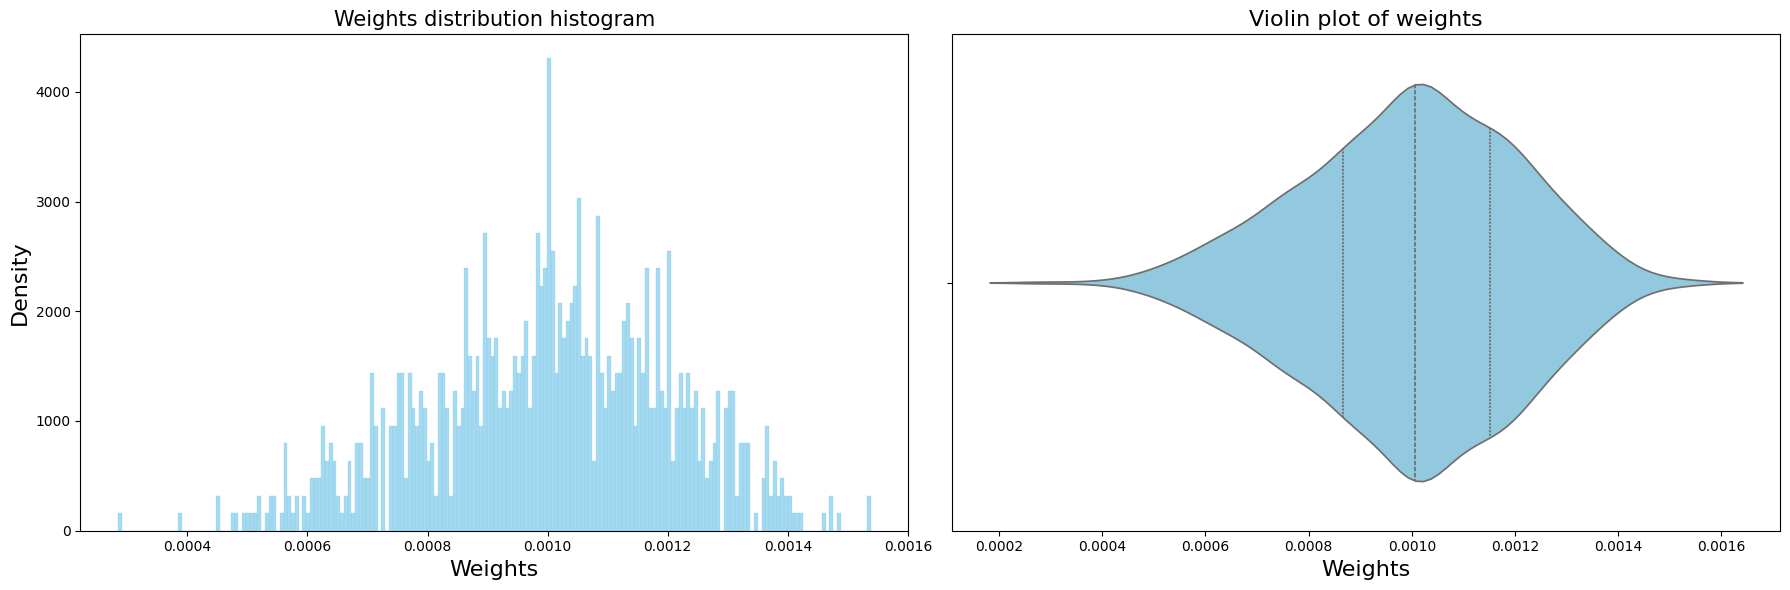

In [8]:
weights = rlwk.weights_
plt.figure(figsize=(18, 6))

# Histogramme
plt.subplot(1, 2, 1)
sns.histplot(weights, bins=200, kde=False, stat='density', color='skyblue', edgecolor='skyblue')
#sns.kdeplot(weights, color='red')
plt.title('Weights distribution histogram', fontsize=15)
plt.xlabel('Weights', fontsize=16)
plt.ylabel('Density', fontsize=16)

# Violin plot
plt.subplot(1, 2, 2)
sns.violinplot(x=weights, inner="quartile", color='skyblue')
plt.title('Violin plot of weights', fontsize=16)
plt.xlabel('Weights', fontsize=16)

plt.tight_layout()
plt.show()

### II. Top terms analysis
__Data processing and cleaning__

In [12]:
import re
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_pattern = re.compile(
    r'\b(?:' + '|'.join(map(re.escape, ENGLISH_STOP_WORDS)) + r')\b'
)

def custom_preprocessor(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    # Remove stopwords
    text = stop_pattern.sub(' ', text)
    # lemmatisation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return ' '.join(tokens)

__Fit Rlwk__

In [13]:
#---- BBC News ----
# Data vectorization
data = pd.read_csv('data/Corpus/bbc news/bbc-text.csv')
vectorizer = CountVectorizer(preprocessor=custom_preprocessor,
                             min_df=5)
mat = vectorizer.fit_transform(data.text)
y = pd.Categorical(data['category']).codes
k = len(set(y))
transformer = TfidfTransformer(norm='l2')
mat_tfidf = transformer.fit_transform(mat)

In [14]:
n = 1
lamb = 1000
alpha = 0.0001
beta = 3
scale = 0
chi2 = 1
init = 's'

mat = mat_tfidf.toarray()

res_nmi, res_ari = [],[]
for i in range(n):
    print('Iteration',i+1,'/',n,end="\r")
    rlwk = Rlwk(k, lambda_val=lamb, alpha=alpha, beta=beta, chi2=chi2, scale=scale, init=init)
    rlwk.fit(mat, verbose=False)
    
    res_nmi += [normalized_mutual_info_score(rlwk.labels_,y)]
    res_ari += [adjusted_rand_score(rlwk.labels_,y)]

print(f'\nNMI: {np.mean(res_nmi):.2f} +/- {np.std(res_nmi):.2f} \nARI: {np.mean(res_ari):.2f} +/- {np.std(res_ari):.2f}')

Iteration 1 / 1
NMI: 0.88 +/- 0.00 
ARI: 0.91 +/- 0.00


__Cluster top terms based on count__

In [15]:
from RLWK.top_terms_utils import get_top_terms_count, get_top_terms_weight, get_top_features

vocabulary = vectorizer.get_feature_names_out()
weights = rlwk.weights_
labels = rlwk.labels_

get_top_terms_count(mat, labels, vocabulary, n_features=10)

{'Cluster 0': {'film': 37.61,
  'award': 21.88,
  'best': 17.67,
  'star': 14.25,
  'band': 12.37,
  'year': 11.93,
  'said': 11.85,
  'oscar': 11.64,
  'music': 11.6,
  'actor': 11.4},
 'Cluster 1': {'said': 23.69,
  'company': 18.28,
  'bank': 17.47,
  'year': 17.18,
  'firm': 17.13,
  'market': 16.87,
  'growth': 16.81,
  'economy': 16.49,
  'sale': 16.0,
  'share': 15.17},
 'Cluster 2': {'mobile': 19.9,
  'phone': 17.51,
  'people': 17.44,
  'technology': 17.17,
  'game': 17.03,
  'said': 16.8,
  'user': 14.92,
  'computer': 14.2,
  'service': 13.61,
  'software': 13.16},
 'Cluster 3': {'game': 21.33,
  'england': 17.73,
  'player': 17.3,
  'win': 16.43,
  'match': 15.86,
  'club': 15.16,
  'said': 14.91,
  'team': 14.65,
  'cup': 14.17,
  'final': 13.25},
 'Cluster 4': {'mr': 36.54,
  'said': 28.01,
  'labour': 26.55,
  'election': 25.67,
  'party': 23.1,
  'blair': 22.49,
  'government': 20.08,
  'tory': 19.61,
  'minister': 17.6,
  'brown': 16.66}}

__Cluster top terms based on weights__

In [16]:
get_top_terms_weight(mat, labels, weights, vocabulary, max_count=500, n_features=10)


{'Cluster 0': {'stern': np.float64(0.08),
  'elvis': np.float64(0.11),
  'presley': np.float64(0.11),
  'broadway': np.float64(0.11),
  'mcfadden': np.float64(0.12),
  'dvd': np.float64(0.13),
  'mtv': np.float64(0.13),
  'soul': np.float64(0.13),
  'vinci': np.float64(0.13),
  'chart': np.float64(0.14)},
 'Cluster 1': {'fiat': np.float64(0.07),
  'gm': np.float64(0.09),
  'bmw': np.float64(0.09),
  'barclays': np.float64(0.09),
  'cairn': np.float64(0.09),
  'ebbers': np.float64(0.1),
  'mci': np.float64(0.1),
  'marsh': np.float64(0.1),
  'boeing': np.float64(0.1),
  'parmalat': np.float64(0.1)},
 'Cluster 2': {'domain': np.float64(0.08),
  'fbi': np.float64(0.08),
  'robot': np.float64(0.09),
  'blog': np.float64(0.11),
  'linux': np.float64(0.11),
  'laser': np.float64(0.11),
  'spyware': np.float64(0.12),
  'patent': np.float64(0.12),
  'vodafone': np.float64(0.12),
  'jeeves': np.float64(0.12)},
 'Cluster 3': {'mirza': np.float64(0.09),
  'glazer': np.float64(0.1),
  'bellamy': n

__R-Lwk top terms__

In [17]:
get_top_features(vocabulary, weights, n_features=20)

{'fiat': np.float64(0.07366391136999552),
 'bez': np.float64(0.08249453532356515),
 'domain': np.float64(0.08326365514600896),
 'cartridge': np.float64(0.08348664001474698),
 'fbi': np.float64(0.08348819758648822),
 'stern': np.float64(0.08481128730980192),
 'isinbayeva': np.float64(0.08520435085233913),
 'mitsubishi': np.float64(0.08601740951842843),
 'lufthansa': np.float64(0.08648716466843158),
 'virgin': np.float64(0.08685698258158399),
 'blackpool': np.float64(0.08815164389711695),
 'wembley': np.float64(0.08830461496229029),
 'hague': np.float64(0.08886900521570022),
 'nissan': np.float64(0.08959959034798286),
 'robot': np.float64(0.08977753141805447),
 'cairn': np.float64(0.08997008876505593),
 'barclays': np.float64(0.09023485645564011),
 'cyprus': np.float64(0.09079930084333386),
 'casino': np.float64(0.09094115232978786),
 'csi': np.float64(0.09117570049509256)}